# 07 — SISAM Air Quality EDA

Explores the SISAM reanalysis air quality dataset to understand
pollution patterns, seasonal variation, and city-level differences
across 2022–2024.

All analysis reads from `data/processed/sisam_clean.parquet`.
No data is modified here.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve()
PROCESSED = ROOT / "data" / "processed"

df = pd.read_parquet(PROCESSED / "sisam_clean.parquet")

# Consistent city colors across all notebooks
city_colors = {
    "Manaus": "#e05c2a",
    "Brasília": "#e0a82a",
    "Belo Horizonte": "#4a9e6b",
    "São Paulo": "#4a7ab5",
    "Porto Alegre": "#7b5ea7",
}

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"Cities: {sorted(df['city'].unique())}")
print(f"\nPollutant ranges:")
for col in ["pm25_ugm3", "pm10_ugm3", "o3_ugm3", "co_mgm3", "no2_ugm3"]:
    print(f"  {col:<12} min={df[col].min():.2f}  max={df[col].max():.2f}  mean={df[col].mean():.2f}")

Shape: (5480, 9)
Date range: 2022-01-01 00:00:00 → 2024-12-31 00:00:00
Cities: ['Belo Horizonte', 'Brasília', 'Manaus', 'Porto Alegre', 'São Paulo']

Pollutant ranges:
  pm25_ugm3    min=1.54  max=155.29  mean=19.10
  pm10_ugm3    min=2.18  max=215.20  mean=26.90
  o3_ugm3      min=8.34  max=95.35  mean=41.41
  co_mgm3      min=0.04  max=1.30  mean=0.19
  no2_ugm3     min=0.07  max=35.53  mean=6.37


## Air quality context — WHO guidelines and dataset extremes

### WHO Air Quality Guidelines (2021 revision)

| Pollutant | WHO Daily Guideline | WHO Annual Guideline |
|---|---|---|
| PM2.5 | 15 μg/m³ | 5 μg/m³ |
| PM10 | 45 μg/m³ | 15 μg/m³ |
| O3 | 100 μg/m³ (8h peak) | — |
| NO2 | 25 μg/m³ | 10 μg/m³ |
| CO | 4 mg/m³ (24h) | — |

Source: World Health Organization — [Global Air Quality Guidelines 2021](https://www.who.int/publications/i/item/9789240034228)

### Brazilian CONAMA Resolution 491/2018 standards

| Pollutant | Daily Standard | Annual Standard |
|---|---|---|
| PM2.5 | 25 μg/m³ | 10 μg/m³ |
| PM10 | 50 μg/m³ | 20 μg/m³ |
| O3 | 130 μg/m³ (8h) | — |
| NO2 | 200 μg/m³ | 40 μg/m³ |
| CO | 10 mg/m³ (8h) | — |

Source: CONAMA — [Resolução nº 491, de 19 de novembro de 2018](https://www.in.gov.br/materia/-/asset_publisher/Kujrw0TZC2Mb/content/id/51058674)

### Dataset extremes (2022–2024, 5 cities)

| Pollutant | Min | Mean | Max | WHO Daily Limit | Mean vs WHO |
|---|---|---|---|---|---|
| PM2.5 (μg/m³) | 1.54 | 19.10 | **155.29** | 15 | **+27% above** |
| PM10 (μg/m³) | 2.18 | 26.90 | **215.20** | 45 | **40% below** |
| O3 (μg/m³) | 8.34 | 41.41 | 95.35 | 100 | Within limit |
| CO (mg/m³) | 0.04 | 0.19 | 1.30 | 4 | Well within |
| NO2 (μg/m³) | 0.07 | 6.37 | 35.53 | 25 | Well within |

### Key observations

- **PM2.5 is the critical pollutant** — the dataset mean of 19.10 μg/m³ already
  exceeds the WHO daily guideline of 15 μg/m³, meaning these cities are on average
  in violation of international air quality standards
- **The PM2.5 peak of 155.29 μg/m³ is more than 10× the WHO guideline** — almost
  certainly a fire season spike during the 2024 drought anomaly
- **PM10 mean is within WHO limits** but the peak of 215.20 μg/m³ is nearly 5×
  the daily guideline — same fire season origin likely
- **O3, CO, and NO2 remain within WHO guidelines** on average — urban traffic
  and industrial pollution are not the dominant air quality concern in this dataset
- Brazilian CONAMA standards are less strict than WHO guidelines — cities may
  comply with national law while still exceeding international health thresholds

### Note on data type
These are **reanalysis estimates**, not direct ground measurements. Values represent
modeled air quality calibrated against satellite observations. Absolute values should
be interpreted with this in mind — relative patterns and anomalies are more reliable
than absolute concentrations.

In [2]:
# Monthly aggregation for time series analysis
df["year_month"] = df["date"].dt.to_period("M")

df_monthly = (
    df.groupby(["city", "year_month"])
    .agg(
        pm25_ugm3=("pm25_ugm3", "mean"),
        pm10_ugm3=("pm10_ugm3", "mean"),
        o3_ugm3=("o3_ugm3", "mean"),
        co_mgm3=("co_mgm3", "mean"),
        no2_ugm3=("no2_ugm3", "mean"),
        year=("year", "first"),
    )
    .reset_index()
)

df_monthly["date"] = df_monthly["year_month"].dt.to_timestamp()

print(f"Monthly rows: {len(df_monthly)}")
print(df_monthly.head(3).to_string(index=False))

Monthly rows: 180
          city year_month  pm25_ugm3  pm10_ugm3   o3_ugm3  co_mgm3  no2_ugm3  year       date
Belo Horizonte    2022-01  11.703548  16.749677 31.676452 0.125484  5.219677  2022 2022-01-01
Belo Horizonte    2022-02  14.980714  20.887857 29.380000 0.147500  5.841429  2022 2022-02-01
Belo Horizonte    2022-03  10.786129  15.671290 34.709677 0.112903  5.902258  2022 2022-03-01


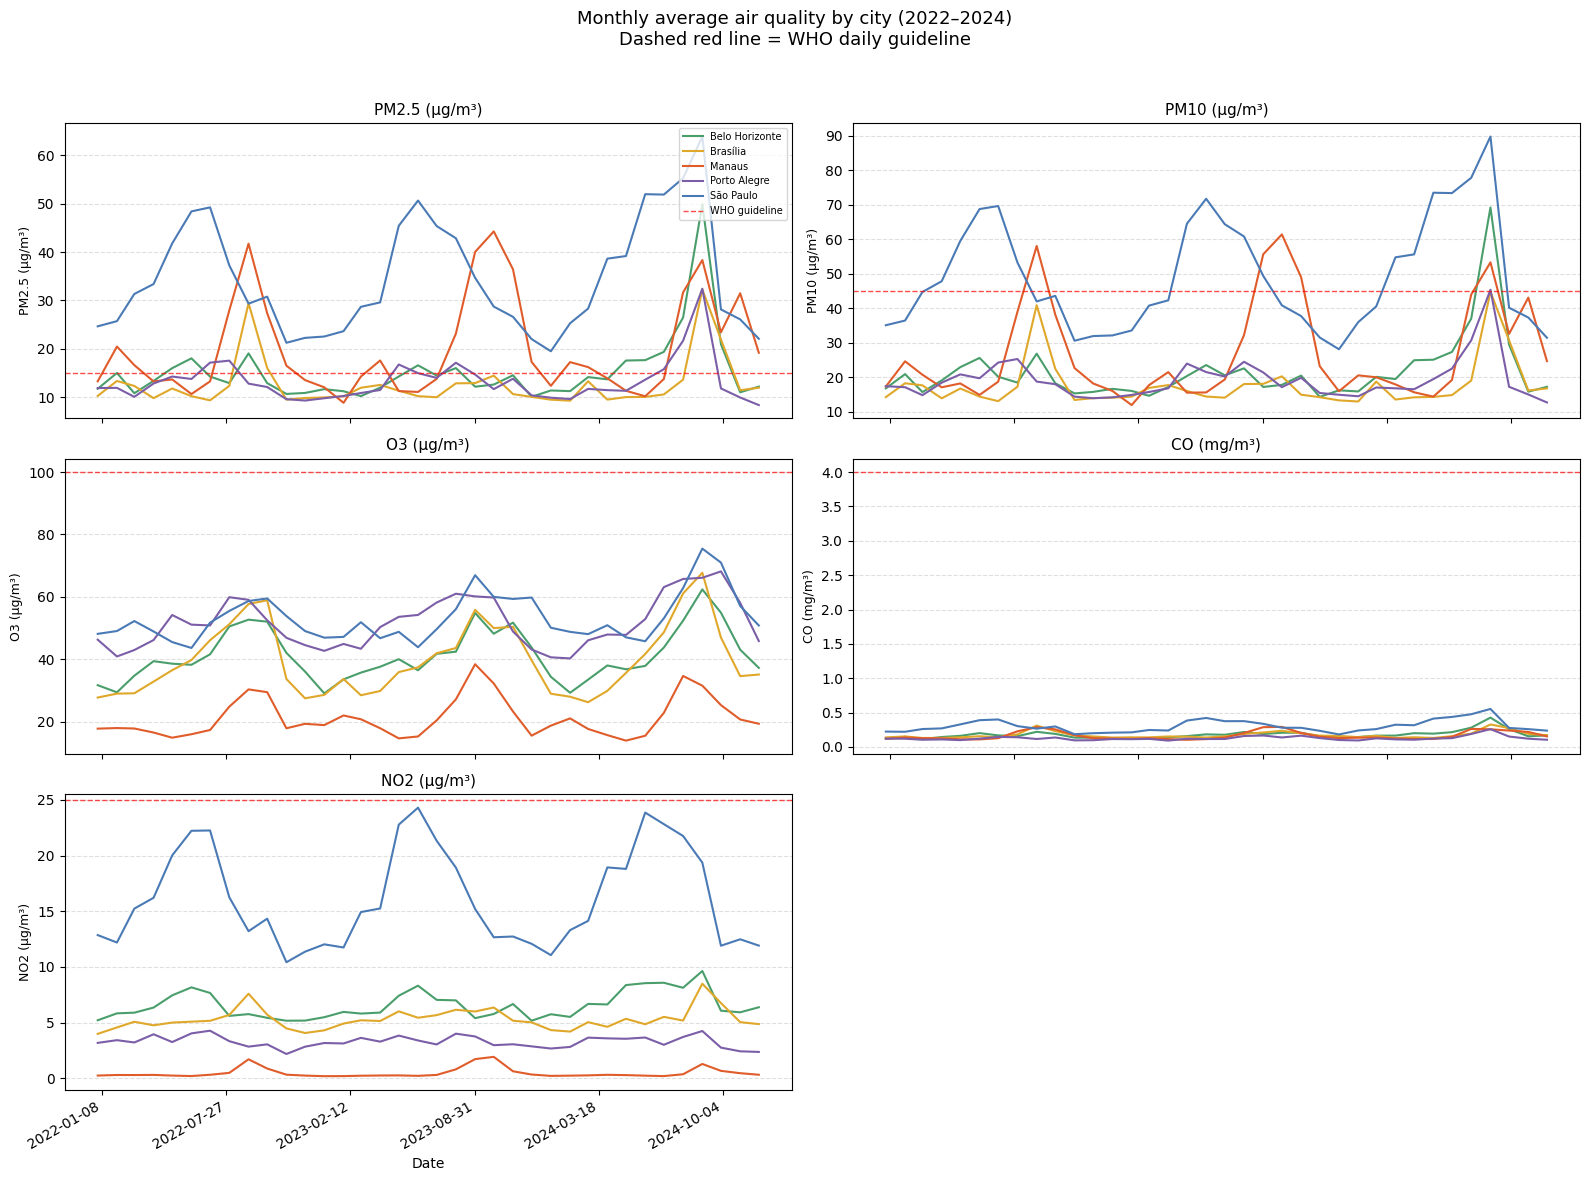

In [3]:
# Question: How does each pollutant evolve over time across cities?
# One subplot per pollutant — reveals which cities are most affected,
# which pollutants are seasonal, and where 2024 anomalies appear

pollutants = {
    "pm25_ugm3": "PM2.5 (μg/m³)",
    "pm10_ugm3": "PM10 (μg/m³)",
    "o3_ugm3":   "O3 (μg/m³)",
    "co_mgm3":   "CO (mg/m³)",
    "no2_ugm3":  "NO2 (μg/m³)",
}

# WHO daily guidelines for reference lines
who_limits = {
    "pm25_ugm3": 15,
    "pm10_ugm3": 45,
    "o3_ugm3":   100,
    "co_mgm3":   4,
    "no2_ugm3":  25,
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))

for i, (col, label) in enumerate(pollutants.items()):
    row = i // 2
    ax_col = i % 2
    ax = axes[row, ax_col]

    for city, group in df_monthly.groupby("city"):
        ax.plot(
            group["date"],
            group[col],
            label=city,
            color=city_colors[city],
            linewidth=1.5,
        )

    # Add WHO guideline as a horizontal dashed red line for reference
    ax.axhline(
        y=who_limits[col],
        color="red",
        linewidth=1,
        linestyle="--",
        alpha=0.7,
        label="WHO guideline",
    )

    ax.set_title(label, fontsize=11)
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlabel("Date")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))

    # Only show legend on first subplot to avoid repetition
    if i == 0:
        ax.legend(loc="upper right", fontsize=7)

# Hide the 6th empty subplot
axes[2, 1].set_visible(False)

fig.suptitle(
    "Monthly average air quality by city (2022–2024)\nDashed red line = WHO daily guideline",
    fontsize=13
)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Finding 1 — Two distinct air quality profiles across the 5 cities

**São Paulo — elevated year-round:**
- PM2.5 consistently above WHO guideline (15 μg/m³) across all 3 years
- Dominates NO2 by a large margin across all cities
- O3 also elevated year-round
- Air quality problems appear structural rather than episodic

**Manaus — low baseline with sharp seasonal spikes:**
- Among the lowest pollution levels outside of mid-year periods
- Sharp PM2.5 and PM10 spikes recurring annually in the same months
- 2024 spikes most extreme of the 3-year period

**BH, Brasília, Porto Alegre — broadly within guidelines:**
- PM2.5 and PM10 within or near WHO limits for most of the year
- Episodic spikes visible in 2022 and 2024, minimal in 2023
- Porto Alegre shows unexpectedly elevated O3 relative to its low NO2 levels

**2023 is noticeably cleaner across all cities:**
- Lower pollution levels across PM2.5, PM10, and O3 compared to 2022 and 2024
- Consistent pattern across all 5 cities simultaneously

**CO and NO2 within WHO limits everywhere except SP:**
- São Paulo is the only city approaching WHO NO2 thresholds
- All other cities show low CO and NO2 year-round

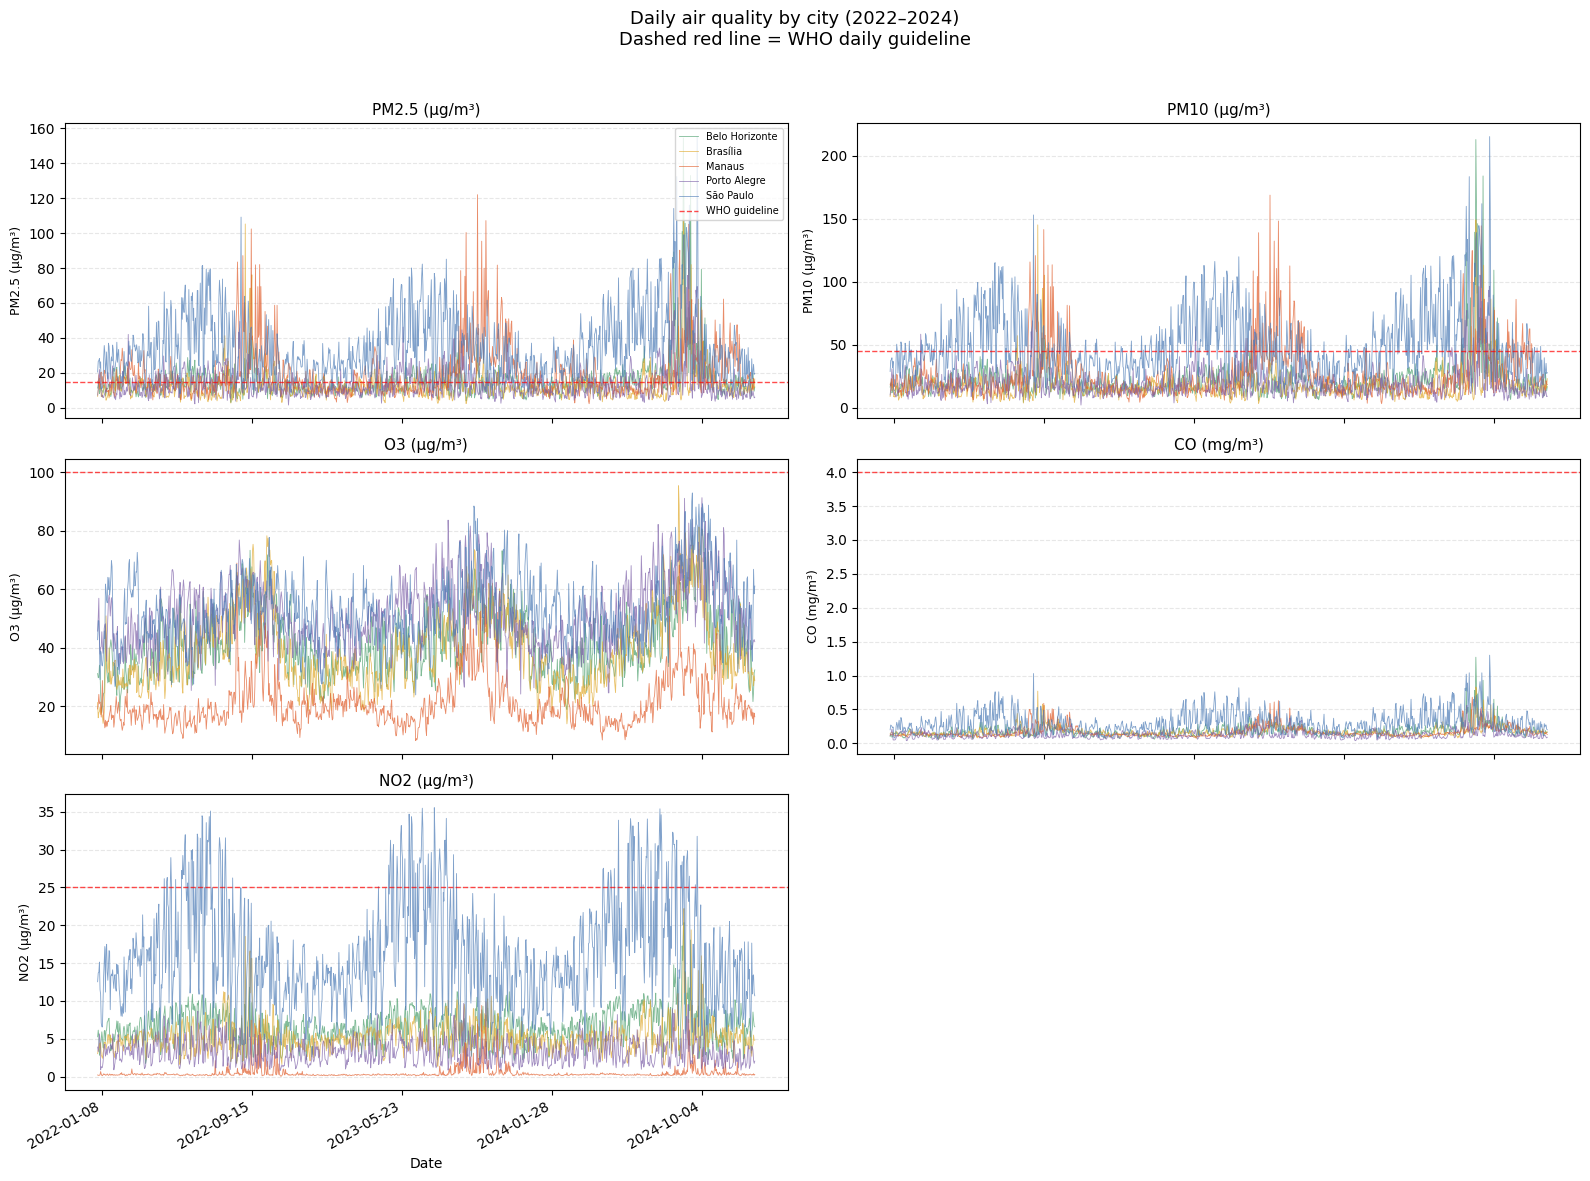

In [4]:
# Raw daily data plot — all 1,096 daily observations per city per pollutant
# Noisier than monthly but reveals individual spikes and extreme events
# that monthly averages smooth over

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))

for i, (col, label) in enumerate(pollutants.items()):
    row = i // 2
    ax_col = i % 2
    ax = axes[row, ax_col]

    for city, group in df.groupby("city"):
        ax.plot(
            group["date"],
            group[col],
            label=city,
            color=city_colors[city],
            linewidth=0.6,   # thinner lines — less visual noise with daily data
            alpha=0.7,
        )

    # WHO guideline reference line
    ax.axhline(
        y=who_limits[col],
        color="red",
        linewidth=1,
        linestyle="--",
        alpha=0.7,
        label="WHO guideline",
    )

    ax.set_title(label, fontsize=11)
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlabel("Date")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))

    if i == 0:
        ax.legend(loc="upper right", fontsize=7)

axes[2, 1].set_visible(False)

fig.suptitle(
    "Daily air quality by city (2022–2024)\nDashed red line = WHO daily guideline",
    fontsize=13
)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

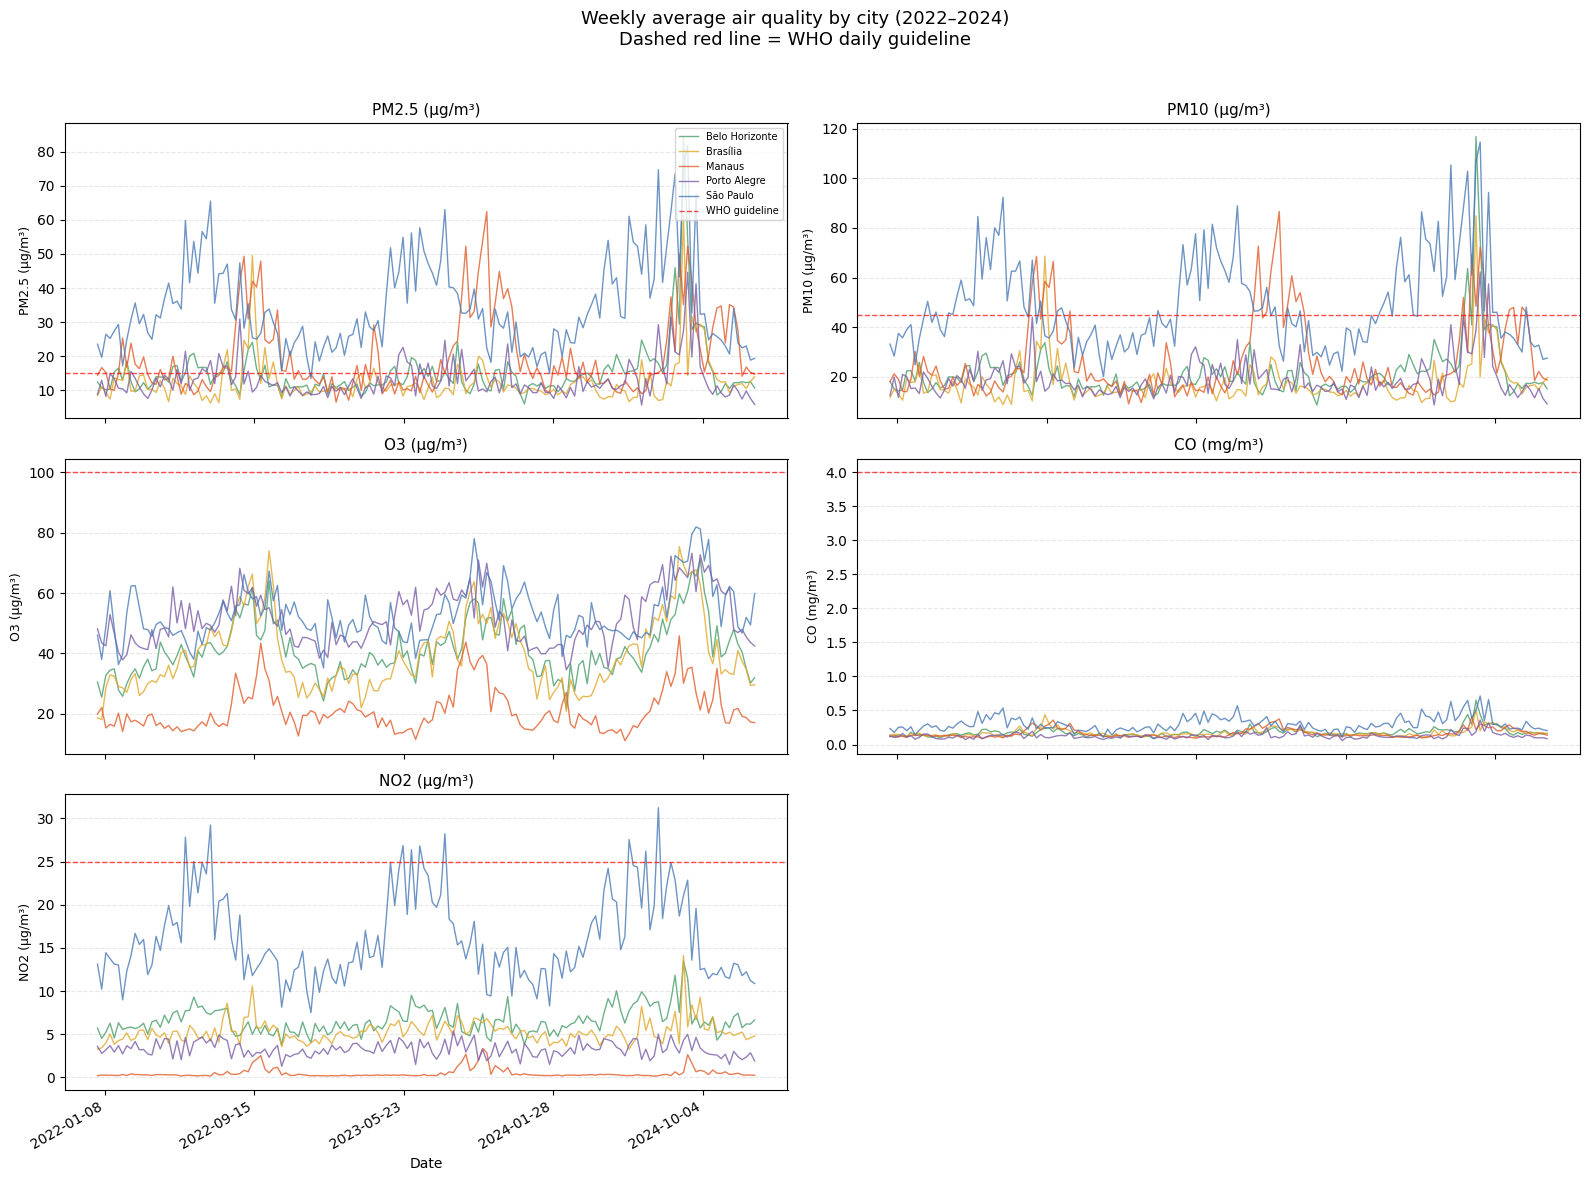

In [5]:
# Weekly average — smoother than daily, less information loss than monthly
# Better reveals sustained pollution periods vs isolated spikes

df["week"] = df["date"].dt.to_period("W").dt.to_timestamp()

df_weekly = (
    df.groupby(["city", "week"])
    .agg(
        pm25_ugm3=("pm25_ugm3", "mean"),
        pm10_ugm3=("pm10_ugm3", "mean"),
        o3_ugm3=("o3_ugm3", "mean"),
        co_mgm3=("co_mgm3", "mean"),
        no2_ugm3=("no2_ugm3", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))

for i, (col, label) in enumerate(pollutants.items()):
    row = i // 2
    ax_col = i % 2
    ax = axes[row, ax_col]

    for city, group in df_weekly.groupby("city"):
        ax.plot(
            group["week"],
            group[col],
            label=city,
            color=city_colors[city],
            linewidth=1,
            alpha=0.8,
        )

    ax.axhline(
        y=who_limits[col],
        color="red",
        linewidth=1,
        linestyle="--",
        alpha=0.7,
        label="WHO guideline",
    )

    ax.set_title(label, fontsize=11)
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlabel("Date")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))

    if i == 0:
        ax.legend(loc="upper right", fontsize=7)

axes[2, 1].set_visible(False)

fig.suptitle(
    "Weekly average air quality by city (2022–2024)\nDashed red line = WHO daily guideline",
    fontsize=13
)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Finding 2 — Daily, weekly and seasonal patterns reveal pollution structure

**Spike vs baseline distinction (daily and weekly views):**
- Manaus and Brasília show narrow, intense spikes — extreme pollution concentrated
  in short episodes with clean air in between
- São Paulo shows an elevated baseline year-round — chronic pollution with
  episodic worsening on top, rarely dropping to clean air levels
- BH and Porto Alegre fall between the two patterns — moderate baseline
  with occasional spikes

**2024 national elevation (weekly view):**
- Simultaneous elevation visible across all 5 cities in the same period
- Not just higher peaks — the sustained duration of elevated readings is
  longer in 2024 compared to 2022 and 2023
- Porto Alegre, normally the cleanest city for particulates, also shows
  elevated PM2.5 and PM10 in the same period

**NO2 guideline breach in São Paulo (weekly view):**
- SP briefly exceeds the WHO NO2 guideline (25 μg/m³) in several weeks
- Monthly averaging masked this — demonstrates the value of higher
  temporal resolution for identifying exceedance events

**2023 is consistently the cleanest year:**
- Visible across all three time resolutions and all pollutants
- Pattern is consistent across all cities simultaneously

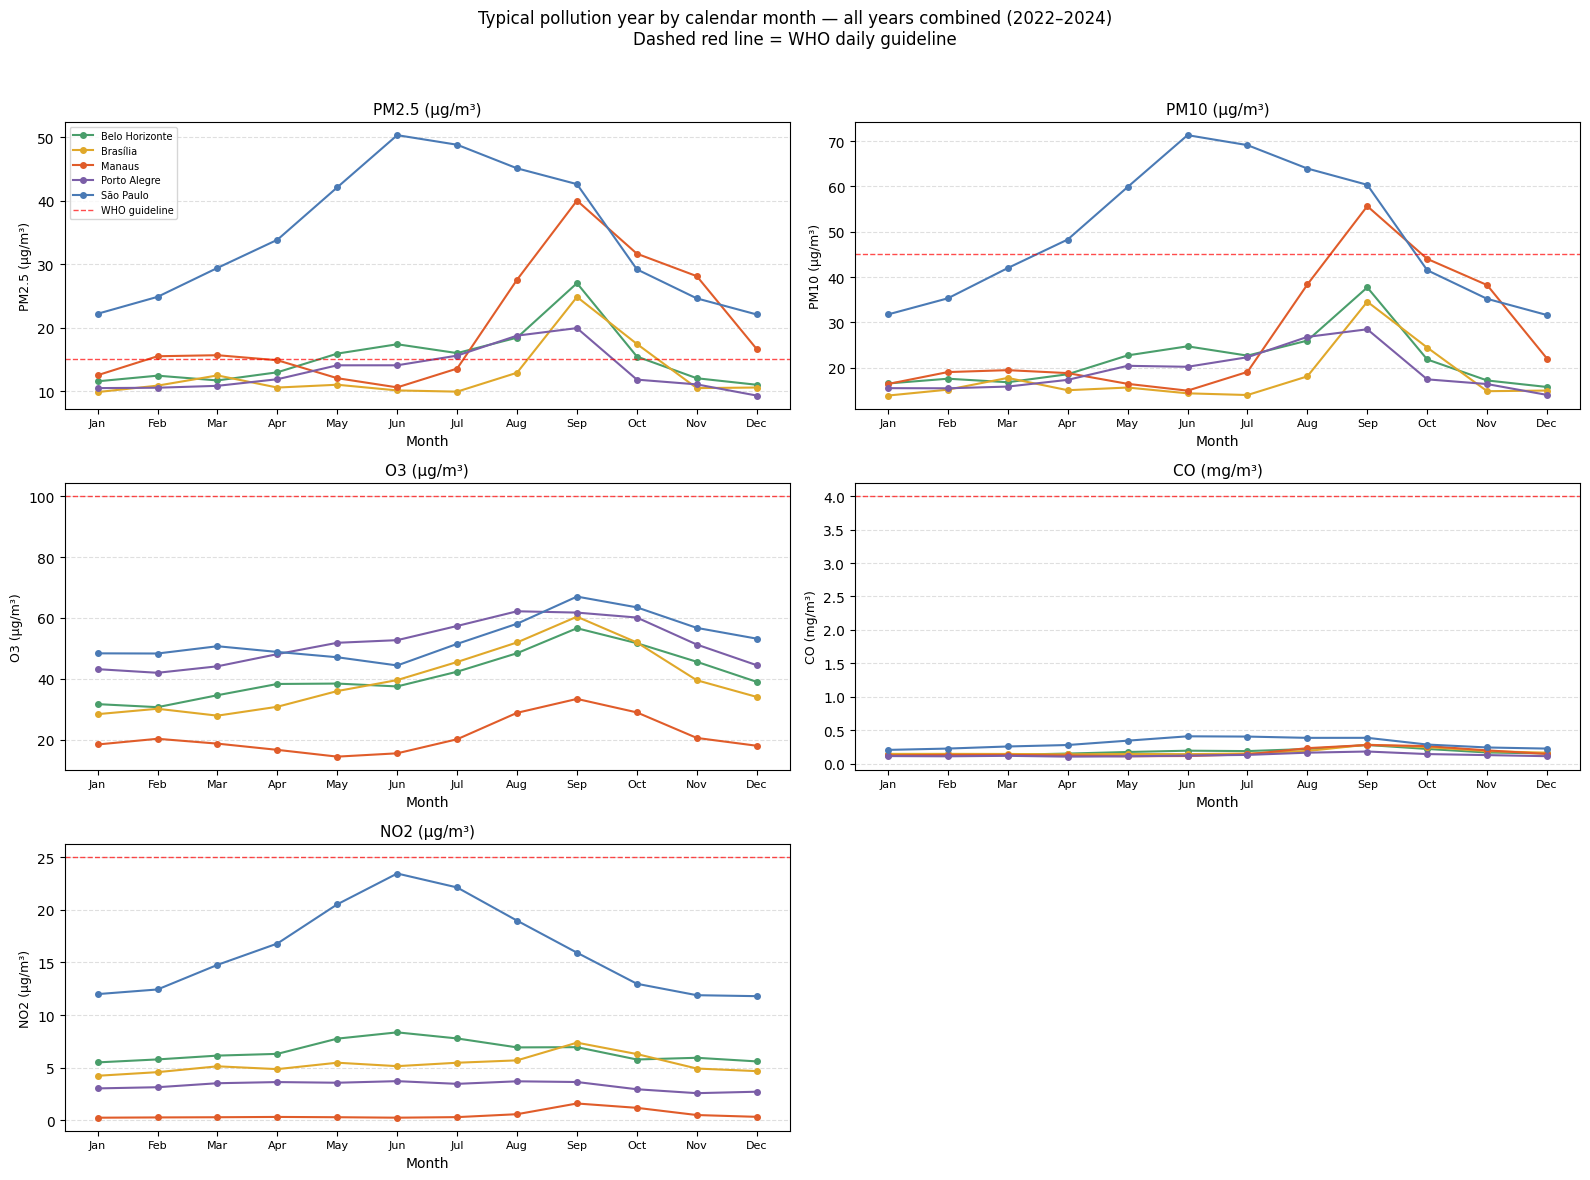

In [6]:
# Typical pollution year — average by calendar month across all years
# Shows the underlying seasonal structure of each pollutant

df["month"] = df["date"].dt.month

df_seasonal = (
    df.groupby(["city", "month"])
    .agg({col: "mean" for col in pollutants.keys()})
    .reset_index()
)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))

for i, (col, label) in enumerate(pollutants.items()):
    row = i // 2
    ax_col = i % 2
    ax = axes[row, ax_col]

    for city, group in df_seasonal.groupby("city"):
        ax.plot(
            group["month"],
            group[col],
            label=city,
            color=city_colors[city],
            linewidth=1.5,
            marker="o",
            markersize=4,
        )

    ax.axhline(
        y=who_limits[col],
        color="red",
        linewidth=1,
        linestyle="--",
        alpha=0.7,
        label="WHO guideline",
    )

    ax.set_title(label, fontsize=11)
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    if i == 0:
        ax.legend(loc="upper left", fontsize=7)

axes[2, 1].set_visible(False)

fig.suptitle(
    "Typical pollution year by calendar month — all years combined (2022–2024)\nDashed red line = WHO daily guideline",
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Finding 3 — Seasonality explains some variation but city-specific factors dominate

- PM2.5 and PM10 show a shared seasonal pattern peaking Aug–Sep across most cities
  but the magnitude differs dramatically — city geography and emission sources
  create distinct profiles that seasonality alone cannot explain
- O3 peaks Aug–Sep universally — the most consistently seasonal pollutant,
  driven by solar radiation and dry conditions across all climate regimes
  — except Manaus, which stays suppressed despite the same season
- NO2 shows no clear seasonal pattern except in São Paulo, where it peaks
  in June–August — consistent with winter temperature inversions trapping
  traffic emissions in the urban basin
- Porto Alegre O3 remains elevated and flat year-round — does not follow
  the seasonal curve of other cities, suggesting a structural driver
  rather than a seasonal one
- Conclusion: integration with weather, geography, and fire data is needed
  to explain residual city-specific variation — seasonality is a starting
  point, not a complete explanation

# SISAM Air Quality EDA Summary

## What the data tells us

**Two distinct air quality profiles:**

- **São Paulo** — chronic elevated pollution year-round. PM2.5 consistently
  above WHO guidelines, NO2 the highest of all cities, elevated O3 from
  traffic-driven photochemical reactions. Air quality problem is structural,
  not seasonal.

- **Manaus** — clean baseline with sharp seasonal spikes. Among the lowest
  pollution levels outside mid-year, then dramatic PM2.5 and PM10 episodes
  concentrated in a short window annually.

- **BH, Brasília, Porto Alegre** — broadly within WHO guidelines outside
  episodic periods. Seasonal spikes visible in 2022 and 2024, minimal in 2023.

**Key pollutant findings:**
- PM2.5 is the critical health concern — dataset mean already exceeds WHO
  guideline, with extreme peaks more than 10× the limit
- O3 is the most consistently seasonal pollutant across cities
- CO and NO2 within safe limits everywhere except SP
- Porto Alegre shows anomalously elevated O3 relative to its emission profile

**2023 is consistently the cleanest year** across all cities and all pollutants —
a coherent pattern across the entire dataset.

**2024 shows simultaneous elevation across all cities** — the most polluted
sustained period in the 3-year dataset, visible at daily, weekly, and monthly
resolution.

**Seasonality is a starting point, not a complete explanation** — city-specific
geography, emission sources, and meteorological conditions create distinct
profiles that require integration with weather and fire data to fully explain.

## Limitations
- Reanalysis data, not ground measurements — relative patterns more reliable
  than absolute concentrations
- Coverage ends 2024-12-31 — 2025 air quality analysis not possible
- No AQI index computed — raw pollutant concentrations only

## Next steps
- Integration EDA (notebook 08): join SISAM + INMET + hotspots on date + city
- Test hypotheses: does fire activity predict PM2.5 spikes?
- Does weather (humidity, wind, temperature) explain residual variation?
- Modeling (notebook 09): predict PM2.5 from weather and fire variables